# CC3092 — Laboratorio 8: Mini-GPT con muestreo controlado

Se entrena un Mini-GPT a nivel de carácter sobre `tiny_shakespeare`, se implementan desde cero las estrategias de muestreo (greedy, top-k con temperatura, top-p con temperatura) y se generan las muestras pedidas.


In [1]:
import math
import os
import time
import urllib.request

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(1337)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cpu


## Task 1.1 — Dataset, vocabulario y batches

In [2]:
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_PATH = "data/input.txt"
os.makedirs("data", exist_ok=True)

if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

with open(DATA_PATH, "r", encoding="utf-8") as f:
    text = f.read()

print(f"Longitud del texto: {len(text):,} caracteres")
print(text[:200])


Longitud del texto: 1,115,394 caracteres
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [3]:
# Vocabulario de caracteres únicos y mappings bidireccionales char <-> índice.
chars = sorted(set(text))
vocab_size = len(chars)
assert vocab_size == 65, f"Se esperaban 65 caracteres, se obtuvieron {vocab_size}"

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}


def encode(s: str) -> list[int]:
    return [stoi[c] for c in s]


def decode(ids) -> str:
    return "".join(itos[int(i)] for i in ids)


print(f"vocab_size = {vocab_size}")
print("".join(chars))


vocab_size = 65

 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


In [4]:
# Codificación completa y split 90/10 respetando el orden temporal (sin shuffle).
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f"train tokens: {len(train_data):,}  val tokens: {len(val_data):,}")


train tokens: 1,003,854  val tokens: 111,540


In [5]:
block_size = 128
d_model = 128
n_heads = 4
n_layers = 3
batch_size = 64
lr = 3e-4
epochs = 10


In [6]:
def get_batch(split: str) -> tuple[torch.Tensor, torch.Tensor]:
    """Arma un batch [batch_size, block_size]. Y es X desplazado un paso al futuro,
    la factorización autoregresiva estándar de un LM causal."""
    source = train_data if split == "train" else val_data
    ix = torch.randint(0, len(source) - block_size - 1, (batch_size,))
    x = torch.stack([source[i:i + block_size] for i in ix])
    y = torch.stack([source[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)


xb, yb = get_batch("train")
assert xb.shape == yb.shape == (batch_size, block_size)
assert torch.equal(xb[:, 1:], yb[:, :-1])
print("batch shapes ok:", xb.shape, yb.shape)


batch shapes ok: torch.Size([64, 128]) torch.Size([64, 128])


## Task 1.2 — Mini-GPT (decoder-only) y entrenamiento

In [7]:
def causal_mask(length: int, device) -> torch.Tensor:
    # Máscara booleana triangular superior: True = posición bloqueada (futuro).
    # Impide que la posición s atienda a tokens s+1, s+2, ... (factorización autoregresiva).
    return torch.triu(
        torch.ones(length, length, dtype=torch.bool, device=device),
        diagonal=1,
    )


class MiniGPT(nn.Module):
    """Decoder-only: embedding de token + posición, bloques Transformer con
    self-attention causal, y una cabeza lineal que proyecta al vocabulario."""

    def __init__(self, vocab_size, d_model, n_heads, n_layers, block_size):
        super().__init__()
        self.block_size = block_size
        self.token = nn.Embedding(vocab_size, d_model)
        self.pos = nn.Embedding(block_size, d_model)
        layer = nn.TransformerEncoderLayer(
            d_model, n_heads, dim_feedforward=4 * d_model,
            dropout=0.1, batch_first=True, norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, ids: torch.Tensor) -> torch.Tensor:
        B, T = ids.shape
        positions = torch.arange(T, device=ids.device)
        x = self.token(ids) + self.pos(positions)[None]
        # attn_mask causal: cada posición solo ve el prefijo permitido.
        x = self.blocks(x, mask=causal_mask(T, ids.device), is_causal=True)
        x = self.ln_f(x)
        return self.lm_head(x)  # [B, T, vocab_size]


model = MiniGPT(vocab_size, d_model, n_heads, n_layers, block_size).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"parámetros entrenables: {n_params:,}")


parámetros entrenables: 628,096


In [8]:
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

# Un "epoch" recorre aproximadamente todo train_data una vez en bloques de batch_size*block_size.
steps_per_epoch = len(train_data) // (batch_size * block_size)
val_eval_batches = 20
print(f"steps_per_epoch = {steps_per_epoch}")


@torch.no_grad()
def estimate_val_loss() -> float:
    model.eval()
    losses = []
    for _ in range(val_eval_batches):
        x, y = get_batch("val")
        logits = model(x)
        loss = F.cross_entropy(logits.reshape(-1, vocab_size), y.reshape(-1))
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)


steps_per_epoch = 122


In [9]:
history = {"train": [], "val": []}
t0 = time.time()

for epoch in range(epochs):
    epoch_losses = []
    for step in range(steps_per_epoch):
        x, y = get_batch("train")
        logits = model(x)
        # Cross-entropy por token: L_t = -log p(x_{t+1} | x_{<=t}).
        loss = F.cross_entropy(logits.reshape(-1, vocab_size), y.reshape(-1))
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    train_loss = sum(epoch_losses) / len(epoch_losses)
    val_loss = estimate_val_loss()
    history["train"].append(train_loss)
    history["val"].append(val_loss)
    print(f"epoch {epoch + 1:2d}/{epochs}  train_loss={train_loss:.4f}  "
          f"val_loss={val_loss:.4f}  elapsed={time.time() - t0:.1f}s")


epoch  1/10  train_loss=2.9947  val_loss=2.6340  elapsed=110.9s
epoch  2/10  train_loss=2.5678  val_loss=2.5155  elapsed=220.8s
epoch  3/10  train_loss=2.4935  val_loss=2.4556  elapsed=331.3s
epoch  4/10  train_loss=2.4389  val_loss=2.3995  elapsed=442.0s
epoch  5/10  train_loss=2.3711  val_loss=2.3180  elapsed=553.0s
epoch  6/10  train_loss=2.2947  val_loss=2.2337  elapsed=664.1s
epoch  7/10  train_loss=2.2215  val_loss=2.1632  elapsed=775.9s
epoch  8/10  train_loss=2.1608  val_loss=2.1137  elapsed=886.2s
epoch  9/10  train_loss=2.1050  val_loss=2.0730  elapsed=997.0s
epoch 10/10  train_loss=2.0615  val_loss=2.0360  elapsed=1108.6s


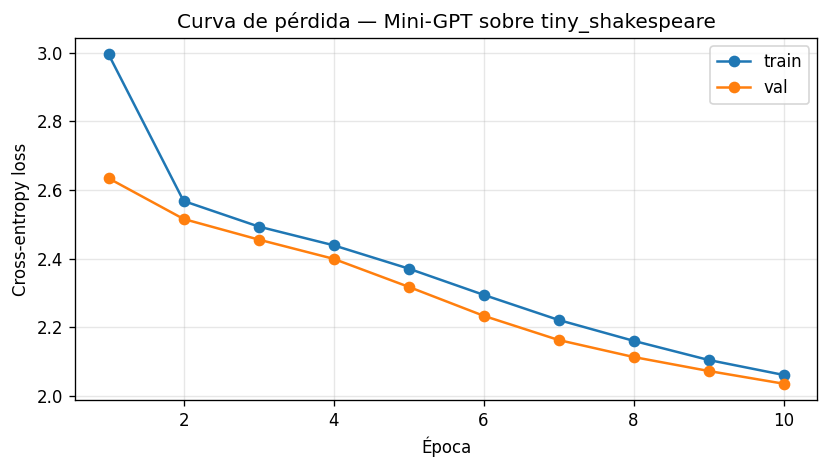

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), history["train"], marker="o", label="train")
plt.plot(range(1, epochs + 1), history["val"], marker="o", label="val")
plt.xlabel("Época")
plt.ylabel("Cross-entropy loss")
plt.title("Curva de pérdida — Mini-GPT sobre tiny_shakespeare")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()


In [11]:
@torch.no_grad()
def full_val_perplexity() -> tuple[float, int]:
    """Perplejidad = exp((1/N) * sum_t L_t) sobre TODOS los targets de
    validación. El último bloque puede ser más corto que block_size."""
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    n_val = len(val_data)

    # Hay n_val - 1 pares entrada/target: x[t] -> x[t + 1].
    for start in range(0, n_val - 1, block_size):
        stop = min(start + block_size, n_val - 1)
        x = val_data[start:stop].unsqueeze(0).to(device)
        y = val_data[start + 1:stop + 1].unsqueeze(0).to(device)
        logits = model(x)
        loss = F.cross_entropy(
            logits.reshape(-1, vocab_size), y.reshape(-1), reduction="sum"
        )
        total_loss += loss.item()
        total_tokens += y.numel()

    model.train()
    mean_loss = total_loss / total_tokens  # (1/N) * sum_t L_t
    return math.exp(mean_loss), total_tokens


val_perplexity, val_tokens_evaluated = full_val_perplexity()
print(f"Perplejidad de validación: {val_perplexity:.3f}")
print(f"Tokens de validación evaluados: {val_tokens_evaluated:,} de {len(val_data) - 1:,}")
assert val_tokens_evaluated == len(val_data) - 1
assert 3.5 <= val_perplexity <= 8.0, "Perplejidad fuera del rango esperado (3.5-8.0)"


Perplejidad de validación: 7.650
Tokens de validación evaluados: 111,539 de 111,539


## Task 1.3 — Muestreo desde cero (greedy, top-k, top-p)

In [12]:
def _validate_logits(logits: torch.Tensor, tau: float | None = None) -> None:
    if logits.ndim != 1:
        raise ValueError("logits debe ser un tensor 1D")
    if tau is not None and tau <= 0:
        raise ValueError("tau debe ser mayor que 0")


def sample_greedy(logits: torch.Tensor) -> int:
    """Greedy: argmax(z_i), sin aleatoriedad."""
    _validate_logits(logits)
    return int(torch.argmax(logits).item())


def sample_top_k(logits: torch.Tensor, k: int, tau: float) -> int:
    """Top-k con temperatura:
    1) z' = z / tau  (P_tau(i) = softmax(z_i/tau))
    2) conservar exactamente los k índices retornados por topk; resto -> -inf
    3) aplicar softmax y muestrear categóricamente.
    """
    _validate_logits(logits, tau)
    if not 1 <= k <= logits.numel():
        raise ValueError(f"k debe estar entre 1 y {logits.numel()}")

    scaled = logits / tau
    top_indices = torch.topk(scaled, k=k).indices
    filtered = torch.full_like(scaled, float("-inf"))
    filtered[top_indices] = scaled[top_indices]
    probs = torch.softmax(filtered, dim=-1)
    return int(torch.multinomial(probs, num_samples=1).item())


def sample_top_p(logits: torch.Tensor, p: float, tau: float) -> int:
    """Top-p / nucleus con temperatura:
    1) z' = z / tau, softmax -> P_tau(i)
    2) ordenar de mayor a menor e incluir el primer conjunto cuya masa llega a p
    3) P_S(i) = P(i)*1[i in S_p] / sum_{j in S_p} P(j)
    4) muestrear categóricamente dentro del núcleo.
    """
    _validate_logits(logits, tau)
    if not 0 < p <= 1:
        raise ValueError("p debe estar en el intervalo (0, 1]")

    probs = torch.softmax(logits / tau, dim=-1)
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)
    cumulative = sorted_probs.cumsum(dim=-1)

    # Se conserva el token que hace que la masa acumulada alcance/supere p.
    keep = cumulative - sorted_probs < p
    nucleus_probs = torch.where(keep, sorted_probs, torch.zeros_like(sorted_probs))
    nucleus_probs = nucleus_probs / nucleus_probs.sum()
    choice = torch.multinomial(nucleus_probs, num_samples=1)
    return int(sorted_idx[choice].item())


In [13]:
# Sanity checks rápidos sobre logits sintéticos.
demo_logits = torch.tensor([5.0, 4.1, 3.5, 2.4, 0.1])
assert sample_greedy(demo_logits) == 0

g_counts = {}
for _ in range(200):
    idx = sample_top_k(demo_logits, k=2, tau=0.7)
    g_counts[idx] = g_counts.get(idx, 0) + 1
assert set(g_counts).issubset({0, 1}), "top-k=2 no debería salir de los 2 mejores logits"

# Si hay empate en el umbral, la función aún conserva exactamente k índices.
tie_logits = torch.tensor([1.0, 1.0, 1.0, 0.0])
allowed_tie = set(torch.topk(tie_logits, k=2).indices.tolist())
seen_tie = {sample_top_k(tie_logits, k=2, tau=1.0) for _ in range(200)}
assert seen_tie.issubset(allowed_tie)

p_counts = {sample_top_p(demo_logits, p=0.5, tau=1.0) for _ in range(200)}
print("top-k=2 counts:", g_counts)
print("top-k empate, índices permitidos/vistos:", allowed_tie, seen_tie)
print("top-p=0.5 índices vistos:", p_counts)


top-k=2 counts: {0: 156, 1: 44}
top-k empate, índices permitidos/vistos: {0, 1} {0, 1}
top-p=0.5 índices vistos: {0}


## Task 2.1 — `generate()` y las 5 configuraciones pedidas

In [14]:
@torch.no_grad()
def generate(prompt: str, max_new_tokens: int, strategy: str, **kwargs) -> str:
    """Genera texto carácter a carácter de forma autoregresiva.

    strategy: "greedy" | "top_k" | "top_p"
    kwargs: parámetros de la estrategia elegida (k, tau, p).
    """
    model.eval()
    ids = encode(prompt)
    for _ in range(max_new_tokens):
        context = torch.tensor([ids[-block_size:]], dtype=torch.long, device=device)
        logits = model(context)
        last_logits = logits[0, -1, :]  # logits del siguiente token

        if strategy == "greedy":
            next_id = sample_greedy(last_logits)
        elif strategy == "top_k":
            next_id = sample_top_k(last_logits, k=kwargs["k"], tau=kwargs["tau"])
        elif strategy == "top_p":
            next_id = sample_top_p(last_logits, p=kwargs["p"], tau=kwargs["tau"])
        else:
            raise ValueError(f"strategy desconocida: {strategy}")

        ids.append(next_id)

    model.train()
    return decode(ids)


In [15]:
configs = {
    "A": dict(strategy="greedy", kwargs={}),
    "B": dict(strategy="top_k", kwargs=dict(k=5, tau=0.7)),
    "C": dict(strategy="top_k", kwargs=dict(k=50, tau=1.0)),
    "D": dict(strategy="top_p", kwargs=dict(p=0.70, tau=0.7)),
    "E": dict(strategy="top_p", kwargs=dict(p=0.95, tau=1.0)),
}

prompt = "ROMEO:"
n_samples = 5
n_chars = 200

samples = {name: [] for name in configs}
for name, cfg in configs.items():
    for _ in range(n_samples):
        text_out = generate(prompt, n_chars, cfg["strategy"], **cfg["kwargs"])
        samples[name].append(text_out)

for name, cfg in configs.items():
    print("=" * 70)
    print(f"Config {name} — {cfg['strategy']} {cfg['kwargs']}")
    print("=" * 70)
    for i, s in enumerate(samples[name], 1):
        print(f"--- muestra {i} ---")
        print(s)
        print()


Config A — greedy {}
--- muestra 1 ---
ROMEO:
What the the the the the so so so the the the sone
And the shat the so the the the stere the the the she so son
The shat the the shat the the she so she the so sone the so sone
The shat the the she s

--- muestra 2 ---
ROMEO:
What the the the the the so so so the the the sone
And the shat the so the the the stere the the the she so son
The shat the the shat the the she so she the so sone the so sone
The shat the the she s

--- muestra 3 ---
ROMEO:
What the the the the the so so so the the the sone
And the shat the so the the the stere the the the she so son
The shat the the shat the the she so she the so sone the so sone
The shat the the she s

--- muestra 4 ---
ROMEO:
What the the the the the so so so the the the sone
And the shat the so the the the stere the the the she so son
The shat the the shat the the she so she the so sone the so sone
The shat the the she s

--- muestra 5 ---
ROMEO:
What the the the the the so so so the the the sone

## Task 2.2 - Respuestas

### a. Repetición/ciclos en greedy (Configuración A)

Las cinco muestras A son idénticas carácter por carácter. La primera fue:

```
ROMEO:
What the the the the the so so so the the the sone
And the shat the so the the the stere the the the she so son
The shat the the shat the the she so she the so sone the so sone
The shat the the she s
```

Greedy aplica $\hat{x}_{t+1}=\arg\max_i z_i$ en cada paso. Como no existe ningún componente aleatorio, el mismo prompt produce siempre la misma trayectoria. Además, continuaciones frecuentes como `"the "` recrean contextos parecidos; el mismo máximo local vuelve a elegirse y el modelo entra en los ciclos observados. Sin temperatura ni muestreo estocástico no hay un mecanismo para escapar de ese atractor.

### b. Top-k con distintos $k$ y $\tau$ (Configuraciones B y C)

**Muestra B1:**

```
ROMEO:
There stere so the some a and a ther the thou ser
I me the and hall a dowen that the so the with sood,
And be shavers the shat that the som my sto stry thime
That hor the anger have shour a trume the
```

**Muestra C1:**

```
ROMEO:
Pet swat this be fork'd col trove hey ne love
Sine of lit. Cty pactee hews, and come'tur woulf ist
goughTis merearmen to to adood atiziontant.

BONGBEMIORK:
AyF rep hat the thau by torciaze de my bla
```

Con $P(w_i\mid\mathrm{ctx})=\dfrac{\exp(z_i/\tau)}{\sum_j\exp(z_j/\tau)}$, aumentar $k$ de 5 a 50 amplía el soporte de la distribución e incorpora caracteres que el modelo considera menos probables. Aumentar $\tau$ de 0.7 a 1.0 reduce la concentración relativa: en B, $\tau<1$ acentúa las diferencias entre logits; en C no hay reescalamiento. En las muestras, **B es más coherente** porque conserva palabras funcionales y estructuras de diálogo con mayor frecuencia, mientras **C es más creativa/diversa** pero produce más palabras inventadas.

### c. Adaptabilidad de top-p=0.95, $\tau=1.0$ (Configuración E)

**Momentos de alta confianza aparente:**

1. La continuación ortográfica `th` -> `the` aparece en E1, E2, E3, E4; en estas transiciones frecuentes pocos caracteres concentran gran parte de la masa.
2. Después de encabezados terminados en dos puntos, el siguiente carácter suele ser un salto de línea (E1 después de `MERENIIZARLE:`, E1 después de `OLA:`, E2 después de `RUS:`), un patrón estructural muy frecuente en el corpus teatral.

**Momentos de incertidumbre aparente:**

1. La primera palabra después del prompt cambia entre E1=`Wer`, E2=`Gir`, E3=`Ay,`, E4=`For`, E5=`to`, señal de que hay varias continuaciones plausibles.
2. Los encabezados o palabras inventadas varían ampliamente (E1=`MERENIIZARLE:`, E1=`OLA:`, E2=`RUS:`); para alcanzar una masa acumulada de 0.95, top-p necesita incluir un núcleo más grande en esas posiciones.


# Task 3

Embeddings contextuales de BERT multilingüe vs. embeddings estáticos de Word2Vec, y las preguntas conceptuales finales.

In [16]:
import gc
import time
from itertools import combinations

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from transformers import AutoModel, AutoTokenizer

# Tasks 1-2 ya terminaron; se libera su modelo antes de cargar BERT.
for _name in ("model", "optimizer"):
    globals().pop(_name, None)
gc.collect()

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
bert_model = AutoModel.from_pretrained("bert-base-multilingual-cased")
bert_model.eval()
print("BERT cargado. dim oculto:", bert_model.config.hidden_size)


BERT cargado. dim oculto: 768


## Task 3.1 — Embeddings contextuales de la palabra objetivo

In [17]:
# (oracion, palabra objetivo, etiqueta de sentido -- la etiqueta es solo para
# identificar cada punto en el PCA de Task 3.2c, no es un input del modelo).
examples = [
    ("El banco central anunció una subida de tasas de interés.", "banco", "banco-financiero"),
    ("Me senté en el banco del parque a leer el periódico.", "banco", "banco-asiento"),
    ("El banco de peces se movió velozmente ante el tiburón.", "banco", "banco-peces"),
    ("El equipo levantó la copa del torneo ante miles de aficionados.", "copa", "copa-trofeo"),
    ("Sirvió una copa de vino tinto para acompañar la cena.", "copa", "copa-vino"),
    ("El velero desplegó su vela para aprovechar el viento.", "vela", "vela-barco"),
    ("Encendió una vela para iluminar el cuarto durante el apagón.", "vela", "vela-cera"),
]


@torch.no_grad()
def contextual_embedding(sentence: str, target_word: str) -> torch.Tensor:
    """Embedding contextual del token (o tokens WordPiece) de target_word en sentence,
    tomado de la última capa de BERT -- NO del token [CLS]."""
    start = sentence.lower().find(target_word.lower())
    if start == -1:
        raise ValueError(f"'{target_word}' no aparece en: {sentence}")
    end = start + len(target_word)

    encoded = bert_tokenizer(sentence, return_offsets_mapping=True, return_tensors="pt")
    offsets = encoded.pop("offset_mapping")[0]

    # WordPiece puede partir la palabra en varias piezas (ids continuados con "##");
    # tomamos todos los tokens cuyo span de caracteres se solapa con [start, end).
    token_idx = [i for i, (s, e) in enumerate(offsets.tolist()) if s < end and e > start]
    if not token_idx:
        raise ValueError(f"No se encontró ningún token para '{target_word}' en: {sentence}")

    outputs = bert_model(**encoded)
    last_hidden = outputs.last_hidden_state[0]  # [seq_len, 768]
    # Si la palabra quedó fragmentada en varios subtokens, se promedian sus vectores:
    # no existe un único "token de la palabra" en WordPiece cuando hay fragmentación.
    return last_hidden[token_idx].mean(dim=0)


embeddings = {}
tokens_used = {}
for sentence, word, sense in examples:
    emb = contextual_embedding(sentence, word)
    assert emb.shape == (768,), emb.shape
    embeddings[sense] = emb

print(f"{len(embeddings)} embeddings de 768-d extraídos:")
for sense in embeddings:
    print(" -", sense)


7 embeddings de 768-d extraídos:
 - banco-financiero
 - banco-asiento
 - banco-peces
 - copa-trofeo
 - copa-vino
 - vela-barco
 - vela-cera


## Task 3.2.a — Similitud coseno entre contextos (BERT)

In [18]:
def cosine_sim(u: torch.Tensor, v: torch.Tensor) -> float:
    # sim(u, v) = (u^T v) / (||u|| * ||v||)
    return torch.nn.functional.cosine_similarity(u.unsqueeze(0), v.unsqueeze(0)).item()


word_groups = {}
for sentence, word, sense in examples:
    word_groups.setdefault(word, []).append(sense)

bert_pair_sims = {}
print(f"{'palabra':<8} {'par de contextos':<38} {'cos_sim (BERT)':>15}")
for word, senses in word_groups.items():
    for a, b in combinations(senses, 2):
        sim = cosine_sim(embeddings[a], embeddings[b])
        bert_pair_sims[(a, b)] = sim
        print(f"{word:<8} {a + ' vs ' + b:<38} {sim:>15.4f}")


palabra  par de contextos                        cos_sim (BERT)
banco    banco-financiero vs banco-asiento               0.5753
banco    banco-financiero vs banco-peces                 0.6603
banco    banco-asiento vs banco-peces                    0.6496
copa     copa-trofeo vs copa-vino                        0.5667
vela     vela-barco vs vela-cera                         0.7999


## Task 3.2.b — Word2Vec estático (SBWC, vía gensim) vs. BERT

In [19]:
from gensim.models import KeyedVectors

SBWC_URL = "https://cs.famaf.unc.edu.ar/~ccardellino/SBWCE/SBW-vectors-300-min5.bin.gz"
SBWC_LIMIT = 20_000

# Gensim lee el formato Word2Vec binario preentrenado de SBWC directamente desde
# el archivo gzip remoto. limit evita materializar el millón de palabras completo;
# las tres palabras objetivo están dentro de los primeros 20 000 vectores.
t0 = time.time()
w2v_model = KeyedVectors.load_word2vec_format(
    SBWC_URL,
    binary=True,
    limit=SBWC_LIMIT,
)
missing = [word for word in word_groups if word not in w2v_model]
if missing:
    raise KeyError(f"Palabras ausentes del vocabulario Word2Vec: {missing}")

print(
    f"Word2Vec (SBWC) cargado con gensim en {time.time() - t0:.1f}s: "
    f"{len(w2v_model):,} palabras, dim={w2v_model.vector_size}"
)
for word in word_groups:
    print(" -", word, w2v_model[word].shape)


Word2Vec (SBWC) cargado con gensim en 5.8s: 20,000 palabras, dim=300
 - banco (300,)
 - copa (300,)
 - vela (300,)


In [20]:
print(f"{'palabra':<8} {'par de contextos':<38} {'cos_sim (Word2Vec)':>19} {'cos_sim (BERT)':>15}")
for word, senses in word_groups.items():
    vec = torch.from_numpy(w2v_model[word].copy())
    for a, b in combinations(senses, 2):
        # Word2Vec asigna el MISMO vector estático sin importar el contexto de la
        # oración, así que sim(u, v) = 1.0 para dos instancias de la misma palabra.
        w2v_sim = cosine_sim(vec, vec)
        print(f"{word:<8} {a + ' vs ' + b:<38} {w2v_sim:>19.4f} {bert_pair_sims[(a, b)]:>15.4f}")


palabra  par de contextos                        cos_sim (Word2Vec)  cos_sim (BERT)
banco    banco-financiero vs banco-asiento                   1.0000          0.5753
banco    banco-financiero vs banco-peces                     1.0000          0.6603
banco    banco-asiento vs banco-peces                        1.0000          0.6496
copa     copa-trofeo vs copa-vino                            1.0000          0.5667
vela     vela-barco vs vela-cera                             1.0000          0.7999


**Discusión 3.2.b:**

Las similitudes de BERT varían entre **0.5667 y 0.7999** y nunca llegan a 1.0. El vector de la palabra cambia con la oración porque la self-attention incorpora el contexto completo de esa instancia.

Word2Vec da **1.0000 en los cinco pares**. Esto es lo esperado: el modelo estático asigna un único vector a cada entrada del vocabulario, independiente de la oración. Comparar dos apariciones de `banco`, `copa` o `vela` equivale a comparar el mismo vector consigo mismo. Por tanto, Word2Vec no puede representar la diferencia entre `banco central` y `banco del parque`, mientras que BERT sí refleja esa diferencia mediante vectores contextuales distintos.


## Task 3.2.c — PCA 2D de los embeddings de BERT

Coordenadas PCA:
  banco-financiero   (  6.745,  -2.074)
  banco-asiento      (  7.159,   0.472)
  banco-peces        (  4.991,  -1.252)
  copa-trofeo        ( -3.267,   5.426)
  copa-vino          ( -3.551,   7.644)
  vela-barco         ( -6.088,  -5.488)
  vela-cera          ( -5.989,  -4.729)


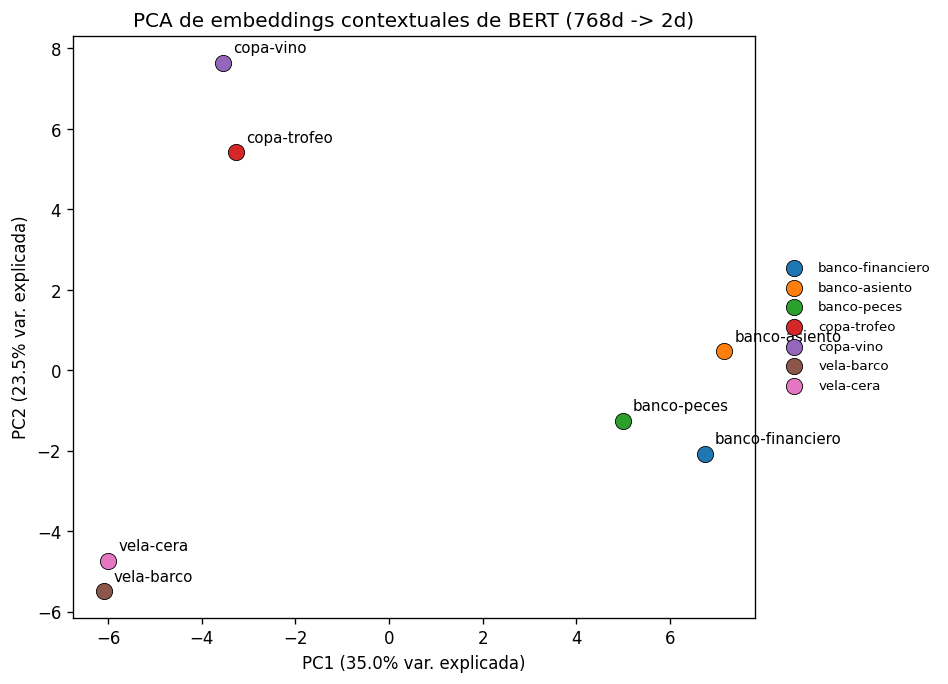

In [ ]:
senses_order = [sense for _, _, sense in examples]
words_order = [word for _, word, _ in examples]
X = torch.stack([embeddings[s] for s in senses_order]).numpy()

# Reduce los 768 componentes de BERT a las 2 direcciones de mayor varianza entre
# estas 7 instancias, únicamente para poder graficarlas en el plano.
pca = PCA(n_components=2)
coords = pca.fit_transform(X)
palette = plt.get_cmap("tab10")
color_by_sense = {sense: palette(i) for i, sense in enumerate(senses_order)}

plt.figure(figsize=(8.0, 5.8))
for (x, y), sense in zip(coords, senses_order):
    plt.scatter(
        x, y, color=color_by_sense[sense], s=95,
        edgecolor="black", linewidth=0.5, label=sense,
    )
    plt.annotate(sense, (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var. explicada)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var. explicada)")
plt.title("PCA de embeddings contextuales de BERT (768d -> 2d)")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig("bert_pca.png", dpi=150, bbox_inches="tight")
plt.show()

print("Coordenadas PCA:")
for sense, (x, y) in zip(senses_order, coords):
    print(f"  {sense:<18} ({x:7.3f}, {y:7.3f})")


**Discusión 3.2.c:**

| Sentido | PC1 | PC2 |
|---|---:|---:|
| banco-financiero | 6.745 | -2.074 |
| banco-asiento | 7.159 | 0.472 |
| banco-peces | 4.991 | -1.252 |
| copa-trofeo | -3.267 | 5.426 |
| copa-vino | -3.551 | 7.644 |
| vela-barco | -6.088 | -5.488 |
| vela-cera | -5.989 | -4.729 |

La identidad léxica domina la proyección: los centroides de palabras distintas están separados entre **11.94 y 13.02** unidades, mientras la mayor distancia entre dos sentidos de una misma palabra es **2.77**. Aun así, las instancias de cada palabra no colapsan en un solo punto: la dispersión interna muestra que BERT conserva diferencias de contexto y significado. El PCA solo proyecta una parte de la varianza, por lo que esta figura es evidencia visual complementaria a las similitudes coseno, no una prueba exhaustiva de separabilidad.


## Task 4.1 — Respuestas

### a. Necesidad de la máscara causal

El objetivo de Language Modeling factoriza la probabilidad de una secuencia de forma autoregresiva:

$$p(x_1,\ldots,x_T)=\prod_{t=1}^{T}p(x_t\mid x_{<t}).$$

Para que entrenar con esa factorización sea válido, el modelo debe calcular $p(x_t\mid x_{<t})$ usando **únicamente** el prefijo $x_{<t}$, nunca $x_t$ ni $x_{>t}$. La máscara causal implementa exactamente esa restricción dentro de la self-attention: en nuestro propio `MiniGPT` (Task 1.2), `causal_mask(T, device)` pone en $-\infty$ (antes del softmax) cualquier conexión de la posición $s$ hacia una posición futura, de modo que la predicción en $s$ solo puede depender de $x_{\le s}$.

Si GPT usara atención bidireccional durante el preentrenamiento, cada posición podría atender directamente al token que se le está pidiendo predecir (y a todo lo que viene después). El objetivo de cross-entropy dejaría de medir la capacidad de predecir el futuro a partir del pasado: el modelo podría "copiar" trivialmente $x_t$ desde sí mismo a través de la atención, haciendo que la pérdida de entrenamiento caiga a casi cero sin que el modelo aprenda ninguna distribución generativa real. El resultado sería un modelo inútil para generación: en inferencia (nuestro `generate()` de Task 2.1) los tokens futuros **no existen todavía**, así que un modelo que aprendió a depender de ellos no tendría ninguna estrategia coherente para producir el siguiente carácter. Por eso la máscara causal no es un detalle de implementación menor, sino la condición que hace que "pérdida baja en entrenamiento" implique "buen modelo generativo", que es exactamente lo que verificamos con la perplejidad de validación (7.65) y las muestras generadas de Task 2.

### b. Preentrenar y adaptar: GPT y BERT no compiten, se complementan

BERT (encoder bidireccional) y GPT (decoder causal) no son dos intentos de resolver el mismo problema del que uno "gana": tienen objetivos de preentrenamiento distintos que los especializan en capacidades distintas. GPT, por construcción causal, es la arquitectura natural para generación autoregresiva (Task 1-2: nuestro Mini-GPT genera texto carácter a carácter razonablemente fluido, con perplejidad 7.650. BERT, por construcción bidireccional, no puede generar de esa forma, pero sí construye representaciones que incorporan contexto de ambos lados a la vez — y el Task 3 lo demuestra numéricamente: el embedding de BERT para "banco" cambia según el contexto (similitudes coseno entre 0.5667 y 0.7999, nunca 1.0), mientras que Word2Vec, al no tener ningún mecanismo de contextualización, da exactamente 1.0 siempre, sin poder distinguir "banco central" de "banco del parque".

Esa es la tensión: ninguna arquitectura por sí sola es la mejor opción para *todas* las tareas (generar texto vs. desambiguar significado). El paradigma de **preentrenar y luego adaptar** resuelve la tensión no haciendo que una sola arquitectura compita por hacer ambas cosas, sino separando las dos decisiones: (1) preentrenar un modelo grande con un objetivo genérico y barato de obtener datos (siguiente token para GPT, tokens enmascarados para BERT) para que absorba estadísticas generales del lenguaje, y (2) **adaptar** ese modelo ya preentrenado —vía fine-tuning, prompting o una cabeza nueva— a la tarea específica que importe. Si la tarea es generar texto, se adapta un GPT; si la tarea es clasificar, extraer información o desambiguar sentido (como en Task 3), se adapta un BERT. En ningún caso hace falta entrenar ninguna arquitectura desde cero para cada tarea nueva: el costo de especializarse se paga una sola vez en el preentrenamiento, y la elección GPT-vs-BERT se convierte en una decisión de ingeniería (qué backbone conviene según la tarea) en lugar de una limitación irresoluble de una sola arquitectura universal.